In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix, 
    mean_squared_error, 
    matthews_corrcoef
)
from sklearn.model_selection import (
    TimeSeriesSplit, 
    cross_val_score, 
    GridSearchCV, 
    train_test_split
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier,VotingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.datasets import load_breast_cancer

import xgboost as xgb

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.base import BaseEstimator, ClassifierMixin

d:\Program Files\Python\Python311\Lib\site-packages\cupy\_environment.py:216: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


In [2]:
df = pd.read_csv('../Feature Engineering/EPL_Final_cleaned_features_v2.csv')
df.head(5)

,Temperature,Humidity,WindDirection,Precipitation,WindSpeed,Home_Prv_FTHG,Home_Prv_HS,Home_Prv_HST,Home_Prv_HF,Home_Prv_HC,...,WeatherCode_Clear,WeatherCode_Clouds,WeatherCode_Drizzle,WeatherCode_Fog,WeatherCode_Haze,WeatherCode_Mist,WeatherCode_Rain,WeatherCode_Snow,Time_of_Day_Afternoon,Time_of_Day_Evening
0,1.589044,-0.947690,0.173322,-0.362486,1.677221,0.561811,0.043716,-0.045927,-0.171534,0.002643,...,0,1,0,0,0,0,0,0,1,0
1,1.917548,-0.815443,0.500378,-0.362486,1.280300,1.363757,2.156421,1.555162,-0.443552,1.065042,...,1,0,0,0,0,0,0,0,1,0
2,1.400248,-0.418701,0.816532,-0.362486,0.273563,0.561811,-0.340412,-0.846471,-1.259605,-0.351490,...,0,1,0,0,0,0,0,0,1,0
3,1.811823,-0.683196,0.500378,-0.362486,0.558625,0.561811,-1.300732,-0.446199,2.004609,-1.413890,...,0,0,0,0,0,0,1,0,1,0
4,2.011946,-0.881566,0.500378,-0.362486,0.558625,1.363757,0.811972,2.355707,0.100484,0.710909,...,1,0,0,0,0,0,0,0,1,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1072 entries, 0 to 1071
Data columns (total 55 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Temperature                1072 non-null   float64
 1   Humidity                   1072 non-null   float64
 2   WindDirection              1072 non-null   float64
 3   Precipitation              1072 non-null   float64
 4   WindSpeed                  1072 non-null   float64
 5   Home_Prv_FTHG              1072 non-null   float64
 6   Home_Prv_HS                1072 non-null   float64
 7   Home_Prv_HST               1072 non-null   float64
 8   Home_Prv_HF                1072 non-null   float64
 9   Home_Prv_HC                1072 non-null   float64
 10  Home_Prv_HY                1072 non-null   float64
 11  Home_Prv_HR                1072 non-null   float64
 12  Away_Prv_FTAG              1072 non-null   float64
 13  Away_Prv_AS                1072 non-null   float

In [3]:
train_data = df[df['season'].isin(['2019-2020', '2020-2021'])]
test_data = df[df['season'] == '2021-2022']

### Model with Weather Data:

In [4]:
# Splitting into features and target variable
X_train = train_data.drop(columns=['FTR','Date', 'Time', 'season','HomeTeam','AwayTeam'])
y_train = train_data['FTR']
X_test = test_data.drop(columns=['FTR','Date', 'Time', 'season','HomeTeam','AwayTeam'])
y_test = test_data['FTR']

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((722, 51), (722,), (350, 51), (350,))

In [5]:
param_lr = {'C': 1, 'max_iter': 10000, 'penalty': 'l2', 'solver': 'liblinear', 'tol': 0.0001}
param_rf = {'max_depth': 5, 'max_features': 0.8, 'max_samples': 1.0, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 50}
param_svm = {'C': 1, 'class_weight': 'balanced', 'gamma': 0.01, 'kernel': 'rbf', 'tol': 0.001}
param_xgb = {'colsample_bytree': 1.0, 'lambda': 10, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 150, 'subsample': 0.8}
param_gbm = {'max_depth': 4, 'num_leaves': 42, 'learning_rate': 0.13867651282378762, 'min_child_samples': 57, 'subsample': 0.6231794015571818, 'colsample_bytree': 0.6335058814681457, 'lambda_l1': 8.071956365090848, 'lambda_l2': 2.8873424651371224}


# Logistic Regression
lr = LogisticRegression(**param_lr)

# Random Forest
rf = RandomForestClassifier(**param_rf, random_state=42)

# Support Vector Machine
svm = SVC(**param_svm, random_state=42)

# XGBoost
xgb = XGBClassifier(**param_xgb, random_state=42)

# LightGBM
lgb = LGBMClassifier(**param_gbm)

# CNN model
# cnn_clf = KerasCNNClassifier(input_shape=(X_train.shape[1], 1), epochs=100, batch_size=32, verbose=1)


[LightGBM] [Warning] lambda_l1 is set=8.071956365090848, reg_alpha=0.0 will be ignored. Current value: lambda_l1=8.071956365090848
[LightGBM] [Warning] lambda_l2 is set=2.8873424651371224, reg_lambda=0.0 will be ignored. Current value: lambda_l2=2.8873424651371224
[LightGBM] [Warning] lambda_l1 is set=8.071956365090848, reg_alpha=0.0 will be ignored. Current value: lambda_l1=8.071956365090848
[LightGBM] [Warning] lambda_l2 is set=2.8873424651371224, reg_lambda=0.0 will be ignored. Current value: lambda_l2=2.8873424651371224
[LightGBM] [Info] Number of positive: 303, number of negative: 419
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000321 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1173
[LightGBM] [Info] Number of data points in the train set: 722, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.419668 -> initscore=-0.324138
[LightGBM] [Info] Start training fro

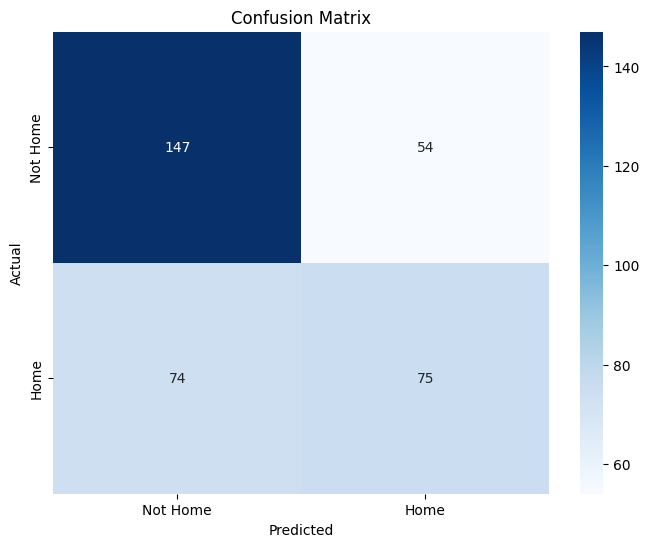

MCC: 0.24055333839304793
accuracy: 0.6342857142857142
              precision    recall  f1-score   support

           0       0.67      0.73      0.70       201
           1       0.58      0.50      0.54       149

    accuracy                           0.63       350
   macro avg       0.62      0.62      0.62       350
weighted avg       0.63      0.63      0.63       350



In [6]:
# Voting Classifier
voting_clf = VotingClassifier(
    estimators=[
        ('lr', lr),
        # ('rf', rf),
        ('svm', svm),
        # ('xgb', xgb),
        ('lgb', lgb)
        # ('cnn', cnn_clf)
    ],
    voting='hard'  # Use 'hard' for majority voting, 'soft' for weighted average probabilities
)

# Train the voting classifier
voting_clf.fit(X_train, y_train)

# Predict on the test set
y_pred = voting_clf.predict(X_test)

# Evaluate the performance
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')


# Calculate accuracy and classification report
mcc = matthews_corrcoef(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
classification_report_output = classification_report(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Home', 'Home'], yticklabels=['Not Home', 'Home'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# print(best_params)
print(f'MCC: {mcc}')
print(f'accuracy: {accuracy}')
print(classification_report_output)

In [7]:
pd.DataFrame(y_pred,columns=['Voting_y_pred']).to_csv('7.Voting_y_pred_with_weather.csv')

Stacking Classifier:

[LightGBM] [Warning] lambda_l1 is set=8.071956365090848, reg_alpha=0.0 will be ignored. Current value: lambda_l1=8.071956365090848
[LightGBM] [Warning] lambda_l2 is set=2.8873424651371224, reg_lambda=0.0 will be ignored. Current value: lambda_l2=2.8873424651371224
[LightGBM] [Warning] lambda_l1 is set=8.071956365090848, reg_alpha=0.0 will be ignored. Current value: lambda_l1=8.071956365090848
[LightGBM] [Warning] lambda_l2 is set=2.8873424651371224, reg_lambda=0.0 will be ignored. Current value: lambda_l2=2.8873424651371224
[LightGBM] [Info] Number of positive: 303, number of negative: 419
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001188 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1173
[LightGBM] [Info] Number of data points in the train set: 722, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.419668 -> initscore=-0.324138
[LightGBM] [Info] Start training fro

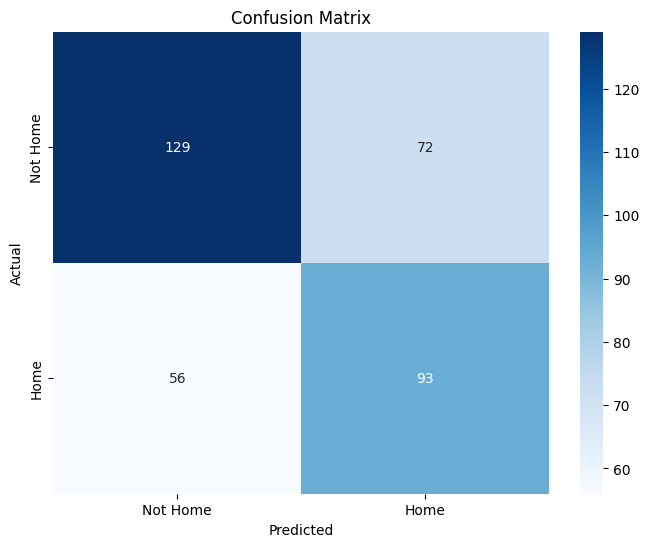

MCC: 0.2634309396023645
Accuracy: 0.6342857142857142
              precision    recall  f1-score   support

           0       0.70      0.64      0.67       201
           1       0.56      0.62      0.59       149

    accuracy                           0.63       350
   macro avg       0.63      0.63      0.63       350
weighted avg       0.64      0.63      0.64       350



In [8]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Define base learners
base_learners = [
    ('lr', lr),
    # ('rf', rf),
    ('svm', svm),
    # ('xgb', xgb),
    ('lgb', lgb)
    # ('cnn', cnn_clf)
]


# Create the Stacking Classifier
stacking_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=svm,
    cv=5  
)

# Train the stacking classifier
stacking_clf.fit(X_train, y_train)

# Predict on the test set
y_pred = stacking_clf.predict(X_test)

# Evaluate the performance
accuracy = accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
classification_report_output = classification_report(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Home', 'Home'], yticklabels=['Not Home', 'Home'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Print evaluation metrics
print(f'MCC: {mcc}')
print(f'Accuracy: {accuracy}')
print(classification_report_output)

In [9]:
pd.DataFrame(y_pred,columns=['Stacking_y_pred']).to_csv('8.Stacking_y_pred_with_weather.csv')

[LightGBM] [Warning] lambda_l1 is set=8.071956365090848, reg_alpha=0.0 will be ignored. Current value: lambda_l1=8.071956365090848
[LightGBM] [Warning] lambda_l2 is set=2.8873424651371224, reg_lambda=0.0 will be ignored. Current value: lambda_l2=2.8873424651371224


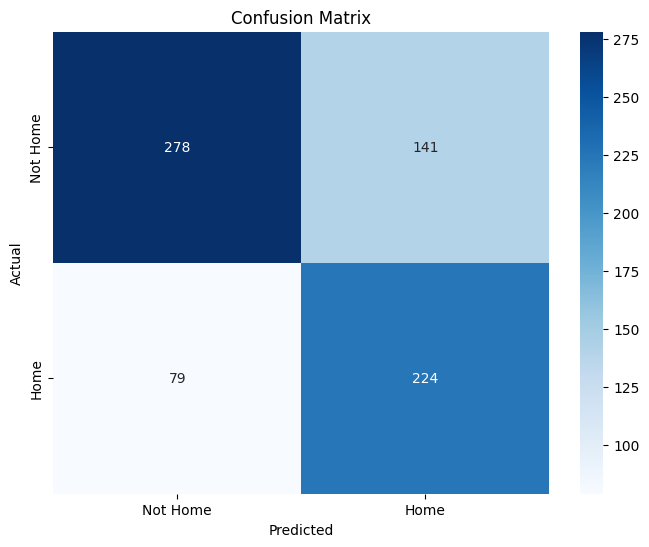

MCC: 0.39755059495745054
accuracy: 0.6952908587257618
              precision    recall  f1-score   support

           0       0.78      0.66      0.72       419
           1       0.61      0.74      0.67       303

    accuracy                           0.70       722
   macro avg       0.70      0.70      0.69       722
weighted avg       0.71      0.70      0.70       722



In [10]:
# Predicting on the TRAIN data
y_pred_train = stacking_clf.predict(X_train)

# Calculate accuracy and classification report
mcc = matthews_corrcoef(y_train, y_pred_train)
accuracy = accuracy_score(y_train, y_pred_train)
classification_report_output = classification_report(y_train, y_pred_train)

cm = confusion_matrix(y_train, y_pred_train)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Home', 'Home'], yticklabels=['Not Home', 'Home'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


print(f'MCC: {mcc}')
print(f'accuracy: {accuracy}')
print(classification_report_output)

In [27]:
result = pd.read_csv('contigency_table.csv')
result.head(5)

,Test Label,LR,RF,SVM,XGB,BO-LightGBM,CNN,Stacking,Hard Voting,B365_Pred,WH_Pred,PS_Pred,Max_Pred
0,0,0,0,1,0,0,0,1,0,0,0,0,0
1,1,0,0,1,1,1,1,1,1,1,1,1,1
2,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1,0,1,1,1,1,0,1,1,1,1,1,1
4,0,0,0,0,0,0,0,0,0,0,0,0,0


In [30]:

contingency_table = pd.crosstab(result['Stacking'], result['B365_Pred'], margins=True, margins_name="Total")
contingency_table


B365_Pred,0,1,Total
Stacking,,,
0,87,49,136
1,47,167,214
Total,134,216,350


In [28]:
contingency_table = pd.crosstab(result['Hard Voting'], result['B365_Pred'], margins=True, margins_name="Total")
contingency_table

B365_Pred,0,1,Total
Hard Voting,,,
0,108,105,213
1,26,111,137
Total,134,216,350


In [ ]:
contingency_table = pd.crosstab(result['Stacking'], result['B365_Pred'], margins=True, margins_name="Total")
contingency_table

Voting with all classifers:

[LightGBM] [Warning] lambda_l1 is set=8.071956365090848, reg_alpha=0.0 will be ignored. Current value: lambda_l1=8.071956365090848
[LightGBM] [Warning] lambda_l2 is set=2.8873424651371224, reg_lambda=0.0 will be ignored. Current value: lambda_l2=2.8873424651371224
[LightGBM] [Warning] lambda_l1 is set=8.071956365090848, reg_alpha=0.0 will be ignored. Current value: lambda_l1=8.071956365090848
[LightGBM] [Warning] lambda_l2 is set=2.8873424651371224, reg_lambda=0.0 will be ignored. Current value: lambda_l2=2.8873424651371224
[LightGBM] [Info] Number of positive: 303, number of negative: 419
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000206 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1173
[LightGBM] [Info] Number of data points in the train set: 722, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.419668 -> initscore=-0.324138
[LightGBM] [Info] Start training fro

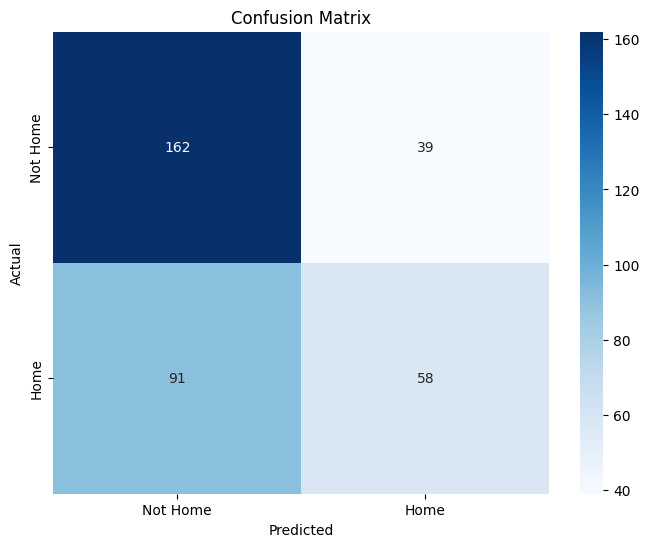

MCC: 0.2156730118258796
accuracy: 0.6285714285714286
              precision    recall  f1-score   support

           0       0.64      0.81      0.71       201
           1       0.60      0.39      0.47       149

    accuracy                           0.63       350
   macro avg       0.62      0.60      0.59       350
weighted avg       0.62      0.63      0.61       350



In [11]:
# Voting Classifier
voting_clf = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('rf', rf),
        ('svm', svm),
        ('xgb', xgb),
        ('lgb', lgb)
        # ('cnn', cnn_clf)
    ],
    voting='hard'  # Use 'hard' for majority voting, 'soft' for weighted average probabilities
)

# Train the voting classifier
voting_clf.fit(X_train, y_train)

# Predict on the test set
y_pred = voting_clf.predict(X_test)

# Evaluate the performance
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')


# Calculate accuracy and classification report
mcc = matthews_corrcoef(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
classification_report_output = classification_report(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Home', 'Home'], yticklabels=['Not Home', 'Home'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# print(best_params)
print(f'MCC: {mcc}')
print(f'accuracy: {accuracy}')
print(classification_report_output)

In [12]:
pd.DataFrame(y_pred,columns=['Voting_y_pred']).to_csv('9.Voting_all_y_pred_with_weather.csv')

Stacking all classifers:

[LightGBM] [Warning] lambda_l1 is set=8.071956365090848, reg_alpha=0.0 will be ignored. Current value: lambda_l1=8.071956365090848
[LightGBM] [Warning] lambda_l2 is set=2.8873424651371224, reg_lambda=0.0 will be ignored. Current value: lambda_l2=2.8873424651371224
[LightGBM] [Warning] lambda_l1 is set=8.071956365090848, reg_alpha=0.0 will be ignored. Current value: lambda_l1=8.071956365090848
[LightGBM] [Warning] lambda_l2 is set=2.8873424651371224, reg_lambda=0.0 will be ignored. Current value: lambda_l2=2.8873424651371224
[LightGBM] [Info] Number of positive: 303, number of negative: 419
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000302 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1173
[LightGBM] [Info] Number of data points in the train set: 722, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.419668 -> initscore=-0.324138
[LightGBM] [Info] Start training fro

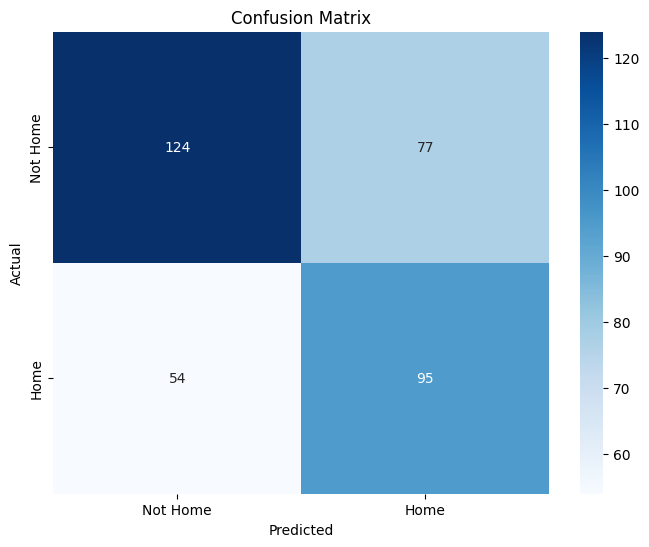

MCC: 0.2517117893301229
Accuracy: 0.6257142857142857
              precision    recall  f1-score   support

           0       0.70      0.62      0.65       201
           1       0.55      0.64      0.59       149

    accuracy                           0.63       350
   macro avg       0.62      0.63      0.62       350
weighted avg       0.64      0.63      0.63       350



In [13]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Define base learners
base_learners = [
    ('lr', lr),
    ('rf', rf),
    ('svm', svm),
    ('xgb', xgb),
    ('lgb', lgb)
    # ('cnn', cnn_clf)
]


# Create the Stacking Classifier
stacking_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=svm,
    cv=5  
)

# Train the stacking classifier
stacking_clf.fit(X_train, y_train)

# Predict on the test set
y_pred = stacking_clf.predict(X_test)

# Evaluate the performance
accuracy = accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
classification_report_output = classification_report(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Home', 'Home'], yticklabels=['Not Home', 'Home'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Print evaluation metrics
print(f'MCC: {mcc}')
print(f'Accuracy: {accuracy}')
print(classification_report_output)

In [14]:
pd.DataFrame(y_pred,columns=['Stacking_y_pred']).to_csv('10.Stacking_All_y_pred_with_weather.csv')

### Model without Weather Data:

In [48]:
# Splitting into features and target variable
X_train = train_data.drop(columns=['FTR','Date', 'Time', 'season','HomeTeam','AwayTeam','Temperature', 'Humidity', 'WindDirection', 'Precipitation', 'WindSpeed', 
                                   'WeatherCode_Clear', 'WeatherCode_Clouds', 'WeatherCode_Drizzle', 'WeatherCode_Fog', 'WeatherCode_Haze', 'WeatherCode_Mist', 'WeatherCode_Rain', 'WeatherCode_Snow'])
y_train = train_data['FTR']
X_test = test_data.drop(columns=['FTR','Date', 'Time', 'season','HomeTeam','AwayTeam','Temperature', 'Humidity', 'WindDirection', 'Precipitation', 'WindSpeed', 
                                   'WeatherCode_Clear', 'WeatherCode_Clouds', 'WeatherCode_Drizzle', 'WeatherCode_Fog', 'WeatherCode_Haze', 'WeatherCode_Mist', 'WeatherCode_Rain', 'WeatherCode_Snow'])
y_test = test_data['FTR']

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((722, 38), (722,), (350, 38), (350,))

In [49]:
param_lr = {'C': 10, 'max_iter': 10000, 'penalty': 'l2', 'solver': 'lbfgs', 'tol': 0.001}
param_rf = {'max_depth': 6, 'max_features': 0.8, 'max_samples': 0.8, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}
param_svm = {'C': 0.1, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf', 'tol': 0.0001}
param_xgb = {'colsample_bytree': 1.0, 'lambda': 10, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 150, 'subsample': 1.0}
param_gbm = {'max_depth': 7, 'num_leaves': 41, 'learning_rate': 0.08605140241894059, 'min_child_samples': 25, 'subsample': 0.8662870932300074, 'colsample_bytree': 0.5489417962266534, 'lambda_l1': 4.323833445713962, 'lambda_l2': 9.431847396075977}


# Logistic Regression
lr = LogisticRegression(**param_lr)

# Random Forest
rf = RandomForestClassifier(**param_rf, random_state=42)

# Support Vector Machine
svm = SVC(**param_svm, random_state=42)

# XGBoost
xgb = XGBClassifier(**param_xgb, random_state=42)

# LightGBM
lgb = LGBMClassifier(**param_gbm)

# CNN model
# cnn_clf = KerasCNNClassifier(input_shape=(X_train.shape[1], 1), epochs=100, batch_size=32, verbose=1)


[LightGBM] [Warning] lambda_l1 is set=4.323833445713962, reg_alpha=0.0 will be ignored. Current value: lambda_l1=4.323833445713962
[LightGBM] [Warning] lambda_l2 is set=9.431847396075977, reg_lambda=0.0 will be ignored. Current value: lambda_l2=9.431847396075977
[LightGBM] [Warning] lambda_l1 is set=4.323833445713962, reg_alpha=0.0 will be ignored. Current value: lambda_l1=4.323833445713962
[LightGBM] [Warning] lambda_l2 is set=9.431847396075977, reg_lambda=0.0 will be ignored. Current value: lambda_l2=9.431847396075977
[LightGBM] [Info] Number of positive: 303, number of negative: 419
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000258 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 699
[LightGBM] [Info] Number of data points in the train set: 722, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.419668 -> initscore=-0.324138
[LightGBM] [Info] Start training from sco

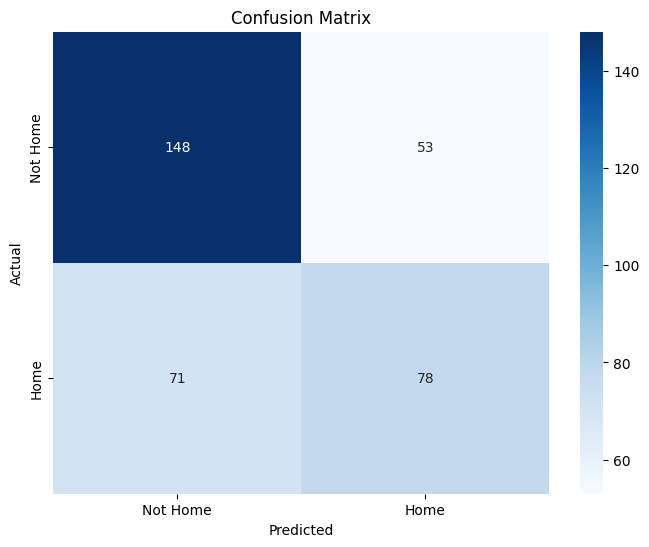

MCC: 0.2654523333312289
accuracy: 0.6457142857142857
              precision    recall  f1-score   support

           0       0.68      0.74      0.70       201
           1       0.60      0.52      0.56       149

    accuracy                           0.65       350
   macro avg       0.64      0.63      0.63       350
weighted avg       0.64      0.65      0.64       350



In [50]:
# Voting Classifier
voting_clf = VotingClassifier(
    estimators=[
        ('lr', lr),
        # ('rf', rf),
        ('svm', svm),
        # ('xgb', xgb),
        ('lgb', lgb)
        # ('cnn', cnn_clf)
    ],
    voting='hard'  # Use 'hard' for majority voting, 'soft' for weighted average probabilities
)

# Train the voting classifier
voting_clf.fit(X_train, y_train)

# Predict on the test set
y_pred = voting_clf.predict(X_test)

# Evaluate the performance
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')


# Calculate accuracy and classification report
mcc = matthews_corrcoef(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
classification_report_output = classification_report(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Home', 'Home'], yticklabels=['Not Home', 'Home'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# print(best_params)
print(f'MCC: {mcc}')
print(f'accuracy: {accuracy}')
print(classification_report_output)

In [51]:
pd.DataFrame(y_pred,columns=['Stacking_y_pred']).to_csv('7.Voting_y_pred_without_weather.csv')

Stacking without weather data:

[LightGBM] [Warning] lambda_l1 is set=4.323833445713962, reg_alpha=0.0 will be ignored. Current value: lambda_l1=4.323833445713962
[LightGBM] [Warning] lambda_l2 is set=9.431847396075977, reg_lambda=0.0 will be ignored. Current value: lambda_l2=9.431847396075977
[LightGBM] [Warning] lambda_l1 is set=4.323833445713962, reg_alpha=0.0 will be ignored. Current value: lambda_l1=4.323833445713962
[LightGBM] [Warning] lambda_l2 is set=9.431847396075977, reg_lambda=0.0 will be ignored. Current value: lambda_l2=9.431847396075977
[LightGBM] [Info] Number of positive: 303, number of negative: 419
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000859 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 699
[LightGBM] [Info] Number of data points in the train set: 722, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.419668 -> initscore=-0.324138
[LightGBM] [Info] Start training from sco

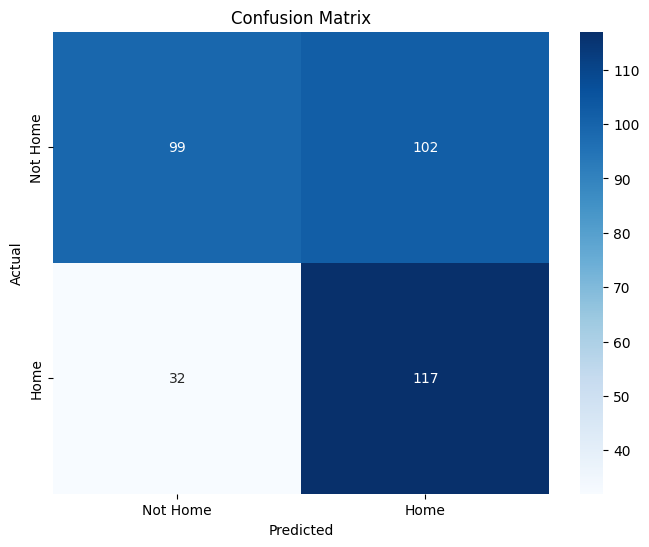

MCC: 0.2838064465984441
Accuracy: 0.6171428571428571
              precision    recall  f1-score   support

           0       0.76      0.49      0.60       201
           1       0.53      0.79      0.64       149

    accuracy                           0.62       350
   macro avg       0.64      0.64      0.62       350
weighted avg       0.66      0.62      0.61       350



In [52]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Define base learners
base_learners = [
    ('lr', lr),
    # ('rf', rf),
    ('svm', svm),
    # ('xgb', xgb)
    ('lgb', lgb)
    # ('cnn', cnn_clf)
]


# Create the Stacking Classifier
stacking_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=svm,
    cv=5
)

# Train the stacking classifier
stacking_clf.fit(X_train, y_train)

# Predict on the test set
y_pred = stacking_clf.predict(X_test)

# Evaluate the performance
accuracy = accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
classification_report_output = classification_report(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Home', 'Home'], yticklabels=['Not Home', 'Home'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Print evaluation metrics
print(f'MCC: {mcc}')
print(f'Accuracy: {accuracy}')
print(classification_report_output)

In [53]:
pd.DataFrame(y_pred,columns=['Stacking_y_pred']).to_csv('8.Stacking_y_pred_without_weather.csv')

Voting all classifiers without weather data:

[LightGBM] [Warning] lambda_l1 is set=4.323833445713962, reg_alpha=0.0 will be ignored. Current value: lambda_l1=4.323833445713962
[LightGBM] [Warning] lambda_l2 is set=9.431847396075977, reg_lambda=0.0 will be ignored. Current value: lambda_l2=9.431847396075977
[LightGBM] [Warning] lambda_l1 is set=4.323833445713962, reg_alpha=0.0 will be ignored. Current value: lambda_l1=4.323833445713962
[LightGBM] [Warning] lambda_l2 is set=9.431847396075977, reg_lambda=0.0 will be ignored. Current value: lambda_l2=9.431847396075977
[LightGBM] [Info] Number of positive: 303, number of negative: 419
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000618 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 699
[LightGBM] [Info] Number of data points in the train set: 722, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.419668 -> initscore=-0.324138
[LightGBM] [Info] Start training from sco

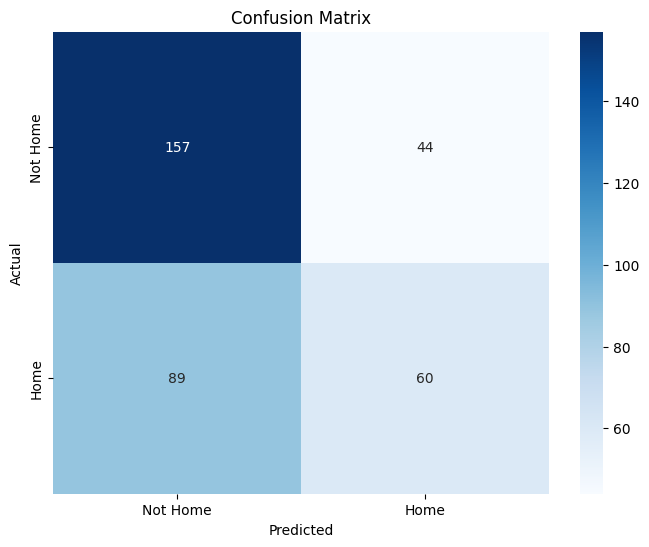

MCC: 0.19883967247692919
accuracy: 0.62
              precision    recall  f1-score   support

           0       0.64      0.78      0.70       201
           1       0.58      0.40      0.47       149

    accuracy                           0.62       350
   macro avg       0.61      0.59      0.59       350
weighted avg       0.61      0.62      0.61       350



In [54]:
# Voting Classifier
voting_clf = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('rf', rf),
        ('svm', svm),
        ('xgb', xgb),
        ('lgb', lgb)
        # ('cnn', cnn_clf)
    ],
    voting='hard'  # Use 'hard' for majority voting, 'soft' for weighted average probabilities
)

# Train the voting classifier
voting_clf.fit(X_train, y_train)

# Predict on the test set
y_pred = voting_clf.predict(X_test)

# Evaluate the performance
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')


# Calculate accuracy and classification report
mcc = matthews_corrcoef(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
classification_report_output = classification_report(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Home', 'Home'], yticklabels=['Not Home', 'Home'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# print(best_params)
print(f'MCC: {mcc}')
print(f'accuracy: {accuracy}')
print(classification_report_output)

In [55]:
pd.DataFrame(y_pred,columns=['Stacking_y_pred']).to_csv('9.Voting_all_y_pred_without_weather.csv')

Stacking all classifiers without weather data:

[LightGBM] [Warning] lambda_l1 is set=4.323833445713962, reg_alpha=0.0 will be ignored. Current value: lambda_l1=4.323833445713962
[LightGBM] [Warning] lambda_l2 is set=9.431847396075977, reg_lambda=0.0 will be ignored. Current value: lambda_l2=9.431847396075977
[LightGBM] [Warning] lambda_l1 is set=4.323833445713962, reg_alpha=0.0 will be ignored. Current value: lambda_l1=4.323833445713962
[LightGBM] [Warning] lambda_l2 is set=9.431847396075977, reg_lambda=0.0 will be ignored. Current value: lambda_l2=9.431847396075977
[LightGBM] [Info] Number of positive: 303, number of negative: 419
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000488 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 699
[LightGBM] [Info] Number of data points in the train set: 722, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.419668 -> initscore=-0.324138
[LightGBM] [Info] Start training from sco

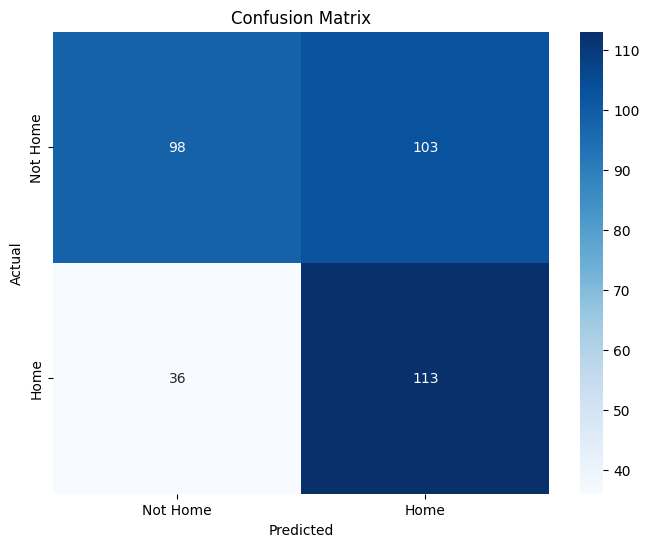

MCC: 0.25018500524640347
Accuracy: 0.6028571428571429
              precision    recall  f1-score   support

           0       0.73      0.49      0.59       201
           1       0.52      0.76      0.62       149

    accuracy                           0.60       350
   macro avg       0.63      0.62      0.60       350
weighted avg       0.64      0.60      0.60       350



In [56]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Define base learners
base_learners = [
    ('lr', lr),
    ('rf', rf),
    ('svm', svm),
    ('xgb', xgb),
    ('lgb', lgb)
    # ('cnn', cnn_clf)
]


# Create the Stacking Classifier
stacking_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=svm,
    cv=5  
)

# Train the stacking classifier
stacking_clf.fit(X_train, y_train)

# Predict on the test set
y_pred = stacking_clf.predict(X_test)

# Evaluate the performance
accuracy = accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
classification_report_output = classification_report(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Home', 'Home'], yticklabels=['Not Home', 'Home'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Print evaluation metrics
print(f'MCC: {mcc}')
print(f'Accuracy: {accuracy}')
print(classification_report_output)

In [57]:
pd.DataFrame(y_pred,columns=['Stacking_y_pred']).to_csv('10.Stacking_All_y_pred_without_weather.csv')